<a href="https://colab.research.google.com/github/RenteriaRaul/Doctorado-DCAG/blob/main/notebooks/sustax/02_sustax_validation_obs_vs_era5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Configuración e imports**

In [12]:
%cd /content/drive/MyDrive/Doctorado-DCAG

import importlib
import scripts.sustax.obs as obs

importlib.reload(obs)

print(obs.__file__)
print("run_obs_pipeline" in dir(obs))
print([x for x in dir(obs) if "obs" in x.lower() or "pipeline" in x.lower()])

/content
/content/drive/MyDrive/Doctorado-DCAG/scripts/sustax/obs.py
True
['build_obs_total', 'compute_obs_idw', 'compute_obs_simple', 'export_obs', 'export_obs_dict', 'export_obs_outputs', 'run_obs_pipeline']


In [13]:
from scripts.sustax.obs import run_obs_pipeline
from scripts.sustax.validation import run_validation_pipeline

print("Imports correctos")

Imports correctos


In [14]:
from google.colab import drive
drive.mount('/content/drive')

import sys
import os
import pandas as pd

PROJECT_PATH = "/content/drive/MyDrive/Doctorado-DCAG"
os.chdir(PROJECT_PATH)
sys.path.append(PROJECT_PATH)

print("Working directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Doctorado-DCAG


# **Imports de scripts**

In [15]:
from scripts.sustax.obs import run_obs_pipeline
from scripts.sustax.validation import run_validation_pipeline

# **Rutas y parámetros de validación**

In [16]:
PROJECT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación"

SUSTAX_DIR = os.path.join(PROJECT_DIR, "Datos Sustax")
MERGED_DIR = os.path.join(SUSTAX_DIR, "SUSTAX_TOTAL_MERGED")
BYSCEN_TOTAL_FOLDER = os.path.join(MERGED_DIR, "BY_SCENARIO_TOTAL")

CONAGUA_COORDS_XLSX = os.path.join(PROJECT_DIR, "estaciones_conagua_excel/Colima/CoordenadasEstacionesColima.xlsx")
CONAGUA_DATA_FOLDER = os.path.join(PROJECT_DIR, "smn_downloads/Estaciones_Colima")

OBS_TOTAL_OUT_FOLDER = os.path.join(SUSTAX_DIR, "OBS_COMPOSITES_TOTAL")
PHASE_A_OUT_FOLDER = os.path.join(SUSTAX_DIR, "PHASE_A_VALIDATION")

R_KM = 50
MAX_N = 8
IDW_P = 2
MIN_STATIONS_PER_DAY = 1

total_summary_path = os.path.join(BYSCEN_TOTAL_FOLDER, "SUSTAX_TOTAL_BYSCEN_summary.csv")
total_points = pd.read_csv(total_summary_path)[["sustax_total", "lat", "lon"]].drop_duplicates()

display(total_points.head())

,sustax_total,lat,lon
0,Sustax_ Manzanillo_LosReyesTotal,18.9695,-104.0625
1,Sustax_CuautitlanTotal,19.5316,-104.3438
2,Sustax_ManzanilloTotal,18.9695,-104.3438
3,Sustax_MexicoTotal,18.9695,-104.6250
4,Sustax_MinatitlanTotal,19.2506,-104.0625


# **OBS compuesta simple e IDW**

In [17]:
neighbors_df, obs_simple_dict, obs_idw_dict, report_df, report_fp = run_obs_pipeline(
    total_points_df=total_points,
    conagua_coords_xlsx=CONAGUA_COORDS_XLSX,
    conagua_data_folder=CONAGUA_DATA_FOLDER,
    out_folder=OBS_TOTAL_OUT_FOLDER,
    r_km=R_KM,
    max_n=MAX_N,
    idw_p=IDW_P,
    min_stations_per_day=MIN_STATIONS_PER_DAY
)

display(neighbors_df.head())
display(report_df.head())
print("Reporte guardado en:", report_fp)

/content/drive/MyDrive/Doctorado-DCAG/scripts/sustax/obs.py:177: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)
/content/drive/MyDrive/Doctorado-DCAG/scripts/sustax/obs.py:177: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)
/content/drive/MyDrive/Doctorado-DCAG/scripts/sustax/obs.py:177: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(out["date"], errors="coerce", dayfirst=True)
/content/drive/MyDrive/Doctorado-DCAG/scripts/sustax/obs.py:177: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=Fal

,sustax_total,sustax_lat,sustax_lon,station_id,distance_km,R_km,MAX_N
0,Sustax_ Manzanillo_LosReyesTotal,18.9695,-104.0625,6074,4.808588,50,8
1,Sustax_ Manzanillo_LosReyesTotal,18.9695,-104.0625,6001,12.693209,50,8
2,Sustax_ Manzanillo_LosReyesTotal,18.9695,-104.0625,6058,20.915601,50,8
3,Sustax_ Manzanillo_LosReyesTotal,18.9695,-104.0625,6017,24.582937,50,8
4,Sustax_ Manzanillo_LosReyesTotal,18.9695,-104.0625,6070,24.742812,50,8


,sustax_total,station_id,status,path
0,Sustax_ Manzanillo_LosReyesTotal,6074,OK,/content/drive/MyDrive/Doctorado /Probabilidad...
1,Sustax_ Manzanillo_LosReyesTotal,6001,OK,/content/drive/MyDrive/Doctorado /Probabilidad...
2,Sustax_ Manzanillo_LosReyesTotal,6058,OK,/content/drive/MyDrive/Doctorado /Probabilidad...
3,Sustax_ Manzanillo_LosReyesTotal,6017,OK,/content/drive/MyDrive/Doctorado /Probabilidad...
4,Sustax_ Manzanillo_LosReyesTotal,6070,OK,/content/drive/MyDrive/Doctorado /Probabilidad...


Reporte guardado en: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/Datos Sustax/OBS_COMPOSITES_TOTAL/OBS_generation_report.csv


# **Validación histórica por punto (AMAX, excedencia, QQ, métricas)**

In [18]:
df_metrics, df_amax, df_all = run_validation_pipeline(
    obs_folder=OBS_TOTAL_OUT_FOLDER,
    era5_folder=BYSCEN_TOTAL_FOLDER,
    out_folder=PHASE_A_OUT_FOLDER
)

display(df_metrics.head())
display(df_amax.head())
display(df_all.head())

/content/drive/MyDrive/Doctorado-DCAG/scripts/sustax/validation.py:15: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
/content/drive/MyDrive/Doctorado-DCAG/scripts/sustax/validation.py:15: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)
/content/drive/MyDrive/Doctorado-DCAG/scripts/sustax/validation.py:15: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  d1 = pd.to_datetime(s, errors="coerce", dayfirst=True)


,point,bias_mm,rmse_mm,correlation,n_obs
0,Sustax_ManzanilloTotal,-0.048824,10.543178,0.508687,15706
1,Sustax_MexicoTotal,0.403056,11.394590,0.465138,15699
2,Sustax_PlayaAzul_ArmeriaTotal,1.007783,10.886954,0.470196,15706
3,Sustax_MinatitlanTotal,1.647490,9.785390,0.470101,15706
4,Sustax_SeaColimaTotal,0.815631,11.612644,0.518352,14347


,point,year,obs_amax,era5_amax
0,Sustax_ManzanilloTotal,1980,58.413204,83.483219
1,Sustax_ManzanilloTotal,1981,60.418630,64.155102
2,Sustax_ManzanilloTotal,1982,236.731076,49.060106
3,Sustax_ManzanilloTotal,1983,81.109065,61.642647
4,Sustax_ManzanilloTotal,1984,68.519230,82.774162


,date,obs_mm,era5_mm,year,month,point,residual_mm
0,1980-01-01,0.0,0.289917,1980,1,Sustax_ManzanilloTotal,0.289917
1,1980-01-02,0.0,0.066757,1980,1,Sustax_ManzanilloTotal,0.066757
2,1980-01-03,0.0,0.139713,1980,1,Sustax_ManzanilloTotal,0.139713
3,1980-01-04,0.0,0.000000,1980,1,Sustax_ManzanilloTotal,0.000000
4,1980-01-05,0.0,0.000000,1980,1,Sustax_ManzanilloTotal,0.000000


# **Figura global final OBS vs ERA5**


Figura: FINAL_validation_OBS_vs_ERA5.png
Existe: True


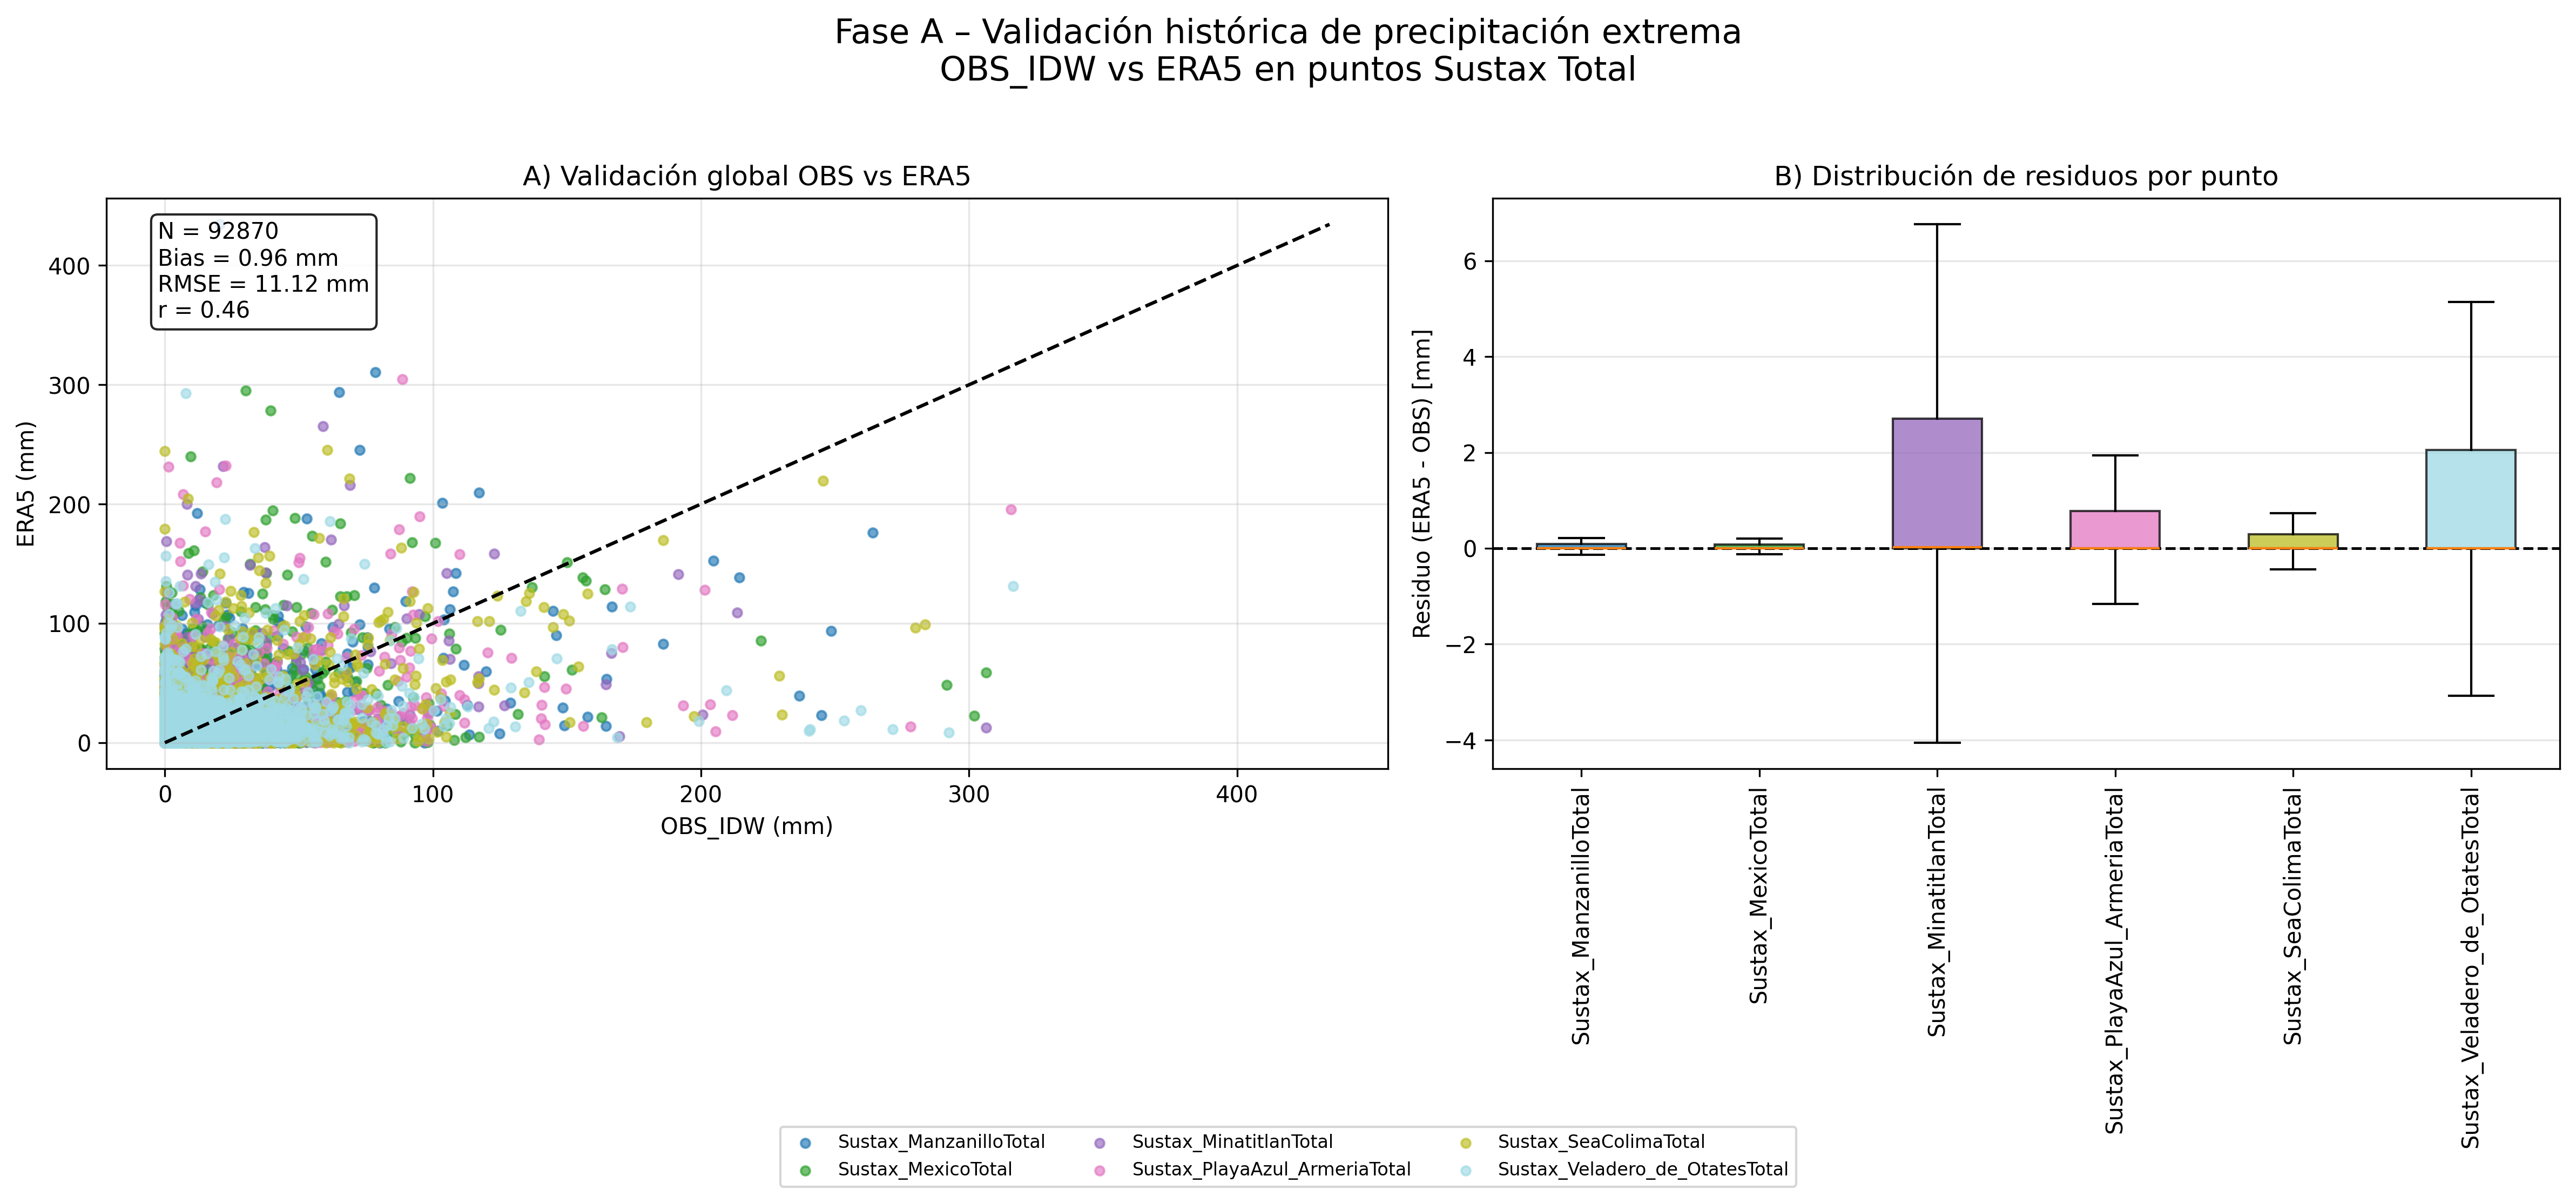

In [20]:
from IPython.display import Image, display
import os

figuras_clave = [
    "FINAL_validation_OBS_vs_ERA5.png",
]

for nombre in figuras_clave:
    fp = os.path.join(PHASE_A_OUT_FOLDER, nombre)
    print("\nFigura:", nombre)
    print("Existe:", os.path.exists(fp))
    if os.path.exists(fp):
        display(Image(filename=fp))